In [1]:
import pandas as pd
import numpy as np

usecols = [
    'TransactionID',      # unique ID - join key
    'isFraud',             # label - ground truth check ke liye
    'TransactionDT',       # timestamp - timing pattern dekhne ke liye
    'TransactionAmt',      # amount
    'ProductCD',           # product category
    'card1', 'card2', 'card3', 'card4', 'card5', 'card6',  # payment card info - ring linking ke liye important
    'addr1', 'addr2',      # billing address - shared address = ring signal
    'dist1', 'dist2',      # distance features (billing vs transaction location)
    'P_emaildomain',       # purchaser email domain
    'R_emaildomain',       # recipient email domain
    'M4', 'M5', 'M6',      # identity mismatch flags (Name/Address match on card)
]

df_txn = pd.read_csv(r"D:\razbuild\train_transaction.csv", usecols=usecols)


In [2]:
df_txn.sample(5)

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,addr2,dist1,dist2,P_emaildomain,R_emaildomain,M4,M5,M6
418969,3405969,0,10604747,161.00,W,12839,321.0,150.0,visa,226.0,debit,264.0,87.0,1004.0,NaN,aol.com,NaN,M0,F,NaN
156298,3143298,0,3258662,28.95,W,6207,355.0,150.0,visa,166.0,debit,441.0,87.0,NaN,NaN,icloud.com,NaN,NaN,NaN,T
277604,3264604,0,6745751,35.95,W,1801,555.0,150.0,visa,226.0,credit,264.0,87.0,11.0,NaN,yahoo.com,NaN,NaN,NaN,F
352372,3339372,0,8703057,34.50,W,12260,236.0,150.0,visa,226.0,debit,204.0,87.0,NaN,NaN,yahoo.com,NaN,M0,T,F
511211,3498211,0,13380125,87.00,W,2803,100.0,150.0,visa,226.0,debit,494.0,87.0,2.0,NaN,aol.com,NaN,M0,F,T


In [3]:
df_txn.isnull().sum()

TransactionID          0
isFraud                0
TransactionDT          0
TransactionAmt         0
ProductCD              0
card1                  0
card2               8933
card3               1565
card4               1577
card5               4259
card6               1571
addr1              65706
addr2              65706
dist1             352271
dist2             552913
P_emaildomain      94456
R_emaildomain     453249
M4                281444
M5                350482
M6                169360
dtype: int64

In [4]:
df_txn.shape

(590540, 20)

In [5]:
usecols_identity = [
    'TransactionID',    # join key (train_transaction se merge karne ke liye)
    'DeviceType',        # mobile / desktop
    'DeviceInfo',        # exact device model/string - strongest linking signal
    'id_01', 'id_02',    # device/network related numeric features
    'id_05', 'id_06',
    'id_11',              # connection-related
    'id_12', 'id_13', 'id_14', 'id_15', 'id_16',  # device/account match signals
    'id_17', 'id_19', 'id_20',                     # IP/network proxy features
    'id_30',              # OS
    'id_31',              # browser
    'id_32',              # screen resolution related
    'id_33',              # screen resolution (exact string, e.g. "1920x1080")
    'id_35', 'id_36', 'id_37', 'id_38',            # match flags (true/false type)
]

df_identity = pd.read_csv(r"D:\razbuild\train_identity.csv", usecols=usecols_identity)


In [6]:
df_identity.sample(5)

,TransactionID,id_01,id_02,id_05,id_06,id_11,id_12,id_13,id_14,id_15,...,id_30,id_31,id_32,id_33,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
116686,3439271,-20.0,242638.0,0.0,-5.0,100.0,NotFound,52.0,NaN,Found,...,NaN,chrome 65.0,NaN,NaN,F,F,T,F,desktop,Windows
83655,3260036,-45.0,77778.0,20.0,-17.0,100.0,NotFound,33.0,-360.0,Found,...,Mac OS X 10_13_1,chrome 64.0,24.0,1920x1080,T,F,T,F,desktop,MacOS
80006,3243313,-20.0,196468.0,0.0,0.0,100.0,NotFound,49.0,NaN,Unknown,...,NaN,mobile safari generic,NaN,NaN,F,F,F,F,mobile,NaN
41799,3087588,-10.0,100090.0,0.0,0.0,100.0,Found,52.0,NaN,Found,...,NaN,chrome 63.0,NaN,NaN,F,F,T,F,desktop,Windows
24939,3055978,-5.0,120146.0,15.0,-31.0,100.0,NotFound,49.0,-300.0,New,...,iOS 10.2.0,mobile safari 10.0,32.0,1334x750,T,F,F,T,mobile,iOS Device


In [7]:
df_identity.shape

(144233, 24)

In [8]:
df = df_txn.merge(df_identity, on='TransactionID', how='left')

# Sort chronologically by TransactionDT
df = df.sort_values('TransactionDT').reset_index(drop=True)


In [9]:
df.sample(5),df.shape

(        TransactionID  isFraud  TransactionDT  TransactionAmt ProductCD  \
 31478         3018478        0         776041           49.00         W   
 437397        3424397        0       11056947           49.00         W   
 453115        3440115        1       11570526           25.00         S   
 89749         3076749        0        1882190          159.95         W   
 265886        3252886        0        6446969           34.00         W   
 
         card1  card2  card3       card4  card5  ...       id_30        id_31  \
 31478   16632  215.0  150.0  mastercard  166.0  ...         NaN          NaN   
 437397   4663  490.0  150.0        visa  166.0  ...         NaN          NaN   
 453115   6054  327.0  150.0    discover  223.0  ...  Windows 10  chrome 65.0   
 89749   14885  240.0  150.0        visa  226.0  ...         NaN          NaN   
 265886   9112  250.0  150.0        visa  226.0  ...         NaN          NaN   
 
         id_32     id_33  id_35 id_36 id_37 id_38 Devi

In [10]:
# === 70/30 TIME-BASED TRAIN/TEST SPLIT SETUP ===
# Split chronologically by TransactionDT to prevent look-ahead leakage

split_dt = df['TransactionDT'].quantile(0.70)
df_train = df[df['TransactionDT'] <= split_dt].copy().reset_index(drop=True)
df_test = df[df['TransactionDT'] > split_dt].copy().reset_index(drop=True)

print(f"=== TIME-BASED TRAIN/TEST DATASET SPLIT ===")
print(f"Total Transactions: {len(df):,}")
print(f"Train Set (70%): {len(df_train):,} transactions (TransactionDT <= {split_dt:,.0f}) | Frauds: {df_train['isFraud'].sum():,} ({df_train['isFraud'].mean():.2%})")
print(f"Test Set (30%):  {len(df_test):,} transactions (TransactionDT > {split_dt:,.0f}) | Frauds: {df_test['isFraud'].sum():,} ({df_test['isFraud'].mean():.2%})")


=== TIME-BASED TRAIN/TEST DATASET SPLIT ===
Total Transactions: 590,540
Train Set (70%): 413,378 transactions (TransactionDT <= 10,437,998) | Frauds: 14,538 (3.52%)
Test Set (30%):  177,162 transactions (TransactionDT > 10,437,998) | Frauds: 6,125 (3.46%)


In [11]:
# === ADDITIONAL FEATURES COVERAGE: Identity Mismatch (M4, M5, M6) & Drop-House (dist1) ===
print(f"Identity Mismatch Coverage:")
print(f"  M4 (Name-on-Card match): {df['M4'].notna().sum():,} non-null ({df['M4'].notna().mean():.1%})")
print(f"  M5 (Address match):      {df['M5'].notna().sum():,} non-null ({df['M5'].notna().mean():.1%})")
print(f"  M6 (Name-Address match): {df['M6'].notna().sum():,} non-null ({df['M6'].notna().mean():.1%})")
print(f"\nDrop-House Distance Coverage:")
print(f"  dist1: {df['dist1'].notna().sum():,} non-null ({df['dist1'].notna().mean():.1%})")
print(f"  dist1 mean: {df['dist1'].mean():.1f}, median: {df['dist1'].median():.1f}, 90th pctile: {df['dist1'].quantile(0.9):.1f}")


Identity Mismatch Coverage:
  M4 (Name-on-Card match): 309,096 non-null (52.3%)
  M5 (Address match):      240,058 non-null (40.7%)
  M6 (Name-Address match): 421,180 non-null (71.3%)

Drop-House Distance Coverage:
  dist1: 238,269 non-null (40.3%)
  dist1 mean: 118.5, median: 8.0, 90th pctile: 268.0


In [27]:
import numpy as np

# Helper function to construct raw multi-signal identity fingerprints
def build_raw_fps(dataframe):
    df_out = dataframe.copy()
    device_mask = df_out['DeviceInfo'].notna() & df_out['id_33'].notna()
    df_out['device_fingerprint'] = np.where(device_mask, df_out['DeviceInfo'].astype(str) + '_' + df_out['id_33'].astype(str), np.nan)
    
    card_mask = df_out['card1'].notna() & df_out['card2'].notna() & df_out['card3'].notna()
    df_out['card_fingerprint'] = np.where(card_mask, df_out['card1'].astype(str) + '_' + df_out['card2'].astype(str) + '_' + df_out['card3'].astype(str), np.nan)
    
    addr_card_mask = df_out['addr1'].notna() & df_out['addr2'].notna() & df_out['card1'].notna()
    df_out['addr_card_fingerprint'] = np.where(addr_card_mask, df_out['addr1'].astype(str) + '_' + df_out['addr2'].astype(str) + '_' + df_out['card1'].astype(str), np.nan)
    
    net_mask = df_out['id_17'].notna() & df_out['id_19'].notna() & df_out['id_20'].notna()
    df_out['network_fingerprint'] = np.where(net_mask, df_out['id_17'].astype(str) + '_' + df_out['id_19'].astype(str) + '_' + df_out['id_20'].astype(str), np.nan)
    return df_out

df_train = build_raw_fps(df_train)
df_test = build_raw_fps(df_test)

# === LEAK-FREE FREQUENCY FILTERING (LEARNED ON TRAIN SET ONLY) ===
MIN_FREQ = 2
MAX_FREQ = 100

def learn_valid_fps(series, min_f=MIN_FREQ, max_f=MAX_FREQ):
    counts = series.value_counts()
    return set(counts[(counts >= min_f) & (counts <= max_f)].index)

valid_device_fps = learn_valid_fps(df_train['device_fingerprint'])
valid_card_fps = learn_valid_fps(df_train['card_fingerprint'])
valid_addr_card_fps = learn_valid_fps(df_train['addr_card_fingerprint'])
valid_network_fps = learn_valid_fps(df_train['network_fingerprint'])

# Assign filtered columns to df_train
df_train['device_fp_filtered'] = df_train['device_fingerprint'].where(df_train['device_fingerprint'].isin(valid_device_fps), np.nan)
df_train['card_fp_filtered'] = df_train['card_fingerprint'].where(df_train['card_fingerprint'].isin(valid_card_fps), np.nan)
df_train['addr_card_fp_filtered'] = df_train['addr_card_fingerprint'].where(df_train['addr_card_fingerprint'].isin(valid_addr_card_fps), np.nan)
df_train['network_fp_filtered'] = df_train['network_fingerprint'].where(df_train['network_fingerprint'].isin(valid_network_fps), np.nan)

print("=== TRAIN-SET LEARNED VALID FINGERPRINTS (FREQ 2-100) ===")
print(f"Device FPs:      {len(valid_device_fps):,} valid types")
print(f"Card FPs:        {len(valid_card_fps):,} valid types")
print(f"Addr+Card FPs:   {len(valid_addr_card_fps):,} valid types")
print(f"Network FPs:     {len(valid_network_fps):,} valid types")


=== TRAIN-SET LEARNED VALID FINGERPRINTS (FREQ 2-100) ===
Device FPs:      584 valid types
Card FPs:        8,432 valid types
Addr+Card FPs:   18,819 valid types
Network FPs:     1,527 valid types


In [28]:
# === TRAIN-SET & TEST-SET SYNTHETIC RING INJECTION ===
# Inject realistic fraud rings into BOTH Train Set & Test Set
# This ensures the ML classifier learns multi-signal ring patterns during training!

import random
import pandas as pd
import numpy as np

def inject_synthetic_rings_to_df(dataframe, prefix='Train'):
    np.random.seed(42 if prefix=='Train' else 84)
    random.seed(42 if prefix=='Train' else 84)
    
    dt_min, dt_max = int(dataframe['TransactionDT'].min()), int(dataframe['TransactionDT'].max())
    current_id = max(df['TransactionID'].max(), 999999) + (100000 if prefix=='Test' else 1)
    
    ring_configs = [
        (15, (5, 15), ['card', 'address'],          'Card+Address Ring'),
        (12, (3, 10), ['device', 'card'],            'Device+Card Ring'),
        (10, (5, 20), ['device', 'card', 'address'], 'Multi-Signal Ring'),
        (8,  (3, 8),  ['card'],                      'Card-Only Ring'),
        (8,  (4, 12), ['device', 'network'],         'Device+Network Ring'),
        (7,  (3, 10), ['card', 'address', 'network'],'Card+Addr+Network Ring'),
    ]
    
    synthetic_ring_map = {}
    synthetic_txn_ids = set()
    all_synth_rows = []
    ring_id = 0
    
    for num_rings, (min_sz, max_sz), signals, desc in ring_configs:
        for _ in range(num_rings):
            ring_id += 1
            ring_size = random.randint(min_sz, max_sz)
            ring_txns = []
            
            s_card1 = (80000 if prefix=='Train' else 90000) + ring_id
            s_card2 = float(random.randint(100, 600))
            s_card3 = 150.0
            s_addr1 = float((70000 if prefix=='Train' else 80000) + ring_id)
            s_addr2 = 87.0
            s_device = f'{prefix}Device-R{ring_id}'
            s_screen = '1920x1080'
            s_id17 = float(900 + ring_id)
            s_id19 = float(random.randint(100, 600))
            s_id20 = float(random.randint(100, 600))
            
            base_time = random.randint(dt_min, dt_max - 7200)
            base_amt = round(random.uniform(25, 300), 2)
            
            for i in range(ring_size):
                txn_id = current_id
                current_id += 1
                ring_txns.append(txn_id)
                synthetic_txn_ids.add(txn_id)
                
                row = {
                    'TransactionID': txn_id,
                    'isFraud': 1,
                    'TransactionDT': base_time + random.randint(0, 3600),
                    'TransactionAmt': round(base_amt + random.uniform(-3, 3), 2),
                    'ProductCD': random.choice(['W', 'C', 'R']),
                    'card1': s_card1 if 'card' in signals else float(random.randint(1000, 18000)),
                    'card2': s_card2 if 'card' in signals else float(random.randint(100, 600)),
                    'card3': s_card3, 'card4': 'visa', 'card5': 226.0, 'card6': 'credit',
                    'addr1': s_addr1 if 'address' in signals else float(random.randint(100, 500)),
                    'addr2': s_addr2,
                    'DeviceInfo': s_device if 'device' in signals else np.nan,
                    'id_33': s_screen if 'device' in signals else np.nan,
                    'id_17': s_id17 if 'network' in signals else np.nan,
                    'id_19': s_id19 if 'network' in signals else np.nan,
                    'id_20': s_id20 if 'network' in signals else np.nan,
                    'id_30': 'Windows 10' if 'device' in signals else np.nan,
                    'id_31': 'chrome 70.0' if 'device' in signals else np.nan,
                    'P_emaildomain': 'gmail.com', 'R_emaildomain': np.nan,
                    'dist1': 45.0, 'dist2': np.nan, 'DeviceType': 'desktop',
                    'id_01': -5.0, 'id_02': 100000.0, 'id_05': 0.0, 'id_06': 0.0,
                    'id_11': 100.0, 'id_12': 'Found', 'id_13': 50.0, 'id_14': -300.0,
                    'id_15': 'Found', 'id_16': 'Found', 'id_32': 24.0,
                    'id_35': 'T', 'id_36': 'F', 'id_37': 'T', 'id_38': 'T',
                    'M4': 'F', 'M5': 'F', 'M6': 'F'
                }
                all_synth_rows.append(row)
            synthetic_ring_map[ring_id] = ring_txns
            
    df_synth = pd.DataFrame(all_synth_rows)
    df_synth = build_raw_fps(df_synth)
    
    counts_dev = df_synth['device_fingerprint'].value_counts()
    valid_dev = set(counts_dev[(counts_dev >= MIN_FREQ) & (counts_dev <= MAX_FREQ)].index)
    counts_card = df_synth['card_fingerprint'].value_counts()
    valid_card = set(counts_card[(counts_card >= MIN_FREQ) & (counts_card <= MAX_FREQ)].index)
    counts_ac = df_synth['addr_card_fingerprint'].value_counts()
    valid_ac = set(counts_ac[(counts_ac >= MIN_FREQ) & (counts_ac <= MAX_FREQ)].index)
    counts_net = df_synth['network_fingerprint'].value_counts()
    valid_net = set(counts_net[(counts_net >= MIN_FREQ) & (counts_net <= MAX_FREQ)].index)
    
    df_out = pd.concat([dataframe, df_synth], ignore_index=True)
    df_out['device_fp_filtered'] = df_out['device_fingerprint'].where(df_out['device_fingerprint'].isin(valid_device_fps.union(valid_dev)), np.nan)
    df_out['card_fp_filtered'] = df_out['card_fingerprint'].where(df_out['card_fingerprint'].isin(valid_card_fps.union(valid_card)), np.nan)
    df_out['addr_card_fp_filtered'] = df_out['addr_card_fingerprint'].where(df_out['addr_card_fingerprint'].isin(valid_addr_card_fps.union(valid_ac)), np.nan)
    df_out['network_fp_filtered'] = df_out['network_fingerprint'].where(df_out['network_fingerprint'].isin(valid_network_fps.union(valid_net)), np.nan)
    return df_out, synthetic_ring_map, len(synthetic_txn_ids)

print("Injecting synthetic rings into Train Set & Test Set...")
df_train, train_synth_map, train_synth_txns = inject_synthetic_rings_to_df(df_train, prefix='Train')
df_test, synthetic_ring_map, total_synth_txns = inject_synthetic_rings_to_df(df_test, prefix='Test')

total_synth_rings = len(synthetic_ring_map)
print(f"Injected 60 synthetic rings into Train Set and 60 synthetic rings into Test Set.")


Injecting synthetic rings into Train Set & Test Set...
Injected 60 synthetic rings into Train Set and 60 synthetic rings into Test Set.


In [29]:
import networkx as nx

def build_ring_graph(dataframe):
    G_out = nx.Graph()
    G_out.add_nodes_from(dataframe['TransactionID'])
    fp_cols = [('device_fp_filtered', 'same_device'), ('card_fp_filtered', 'same_card'),
               ('addr_card_fp_filtered', 'same_address_card'), ('network_fp_filtered', 'same_network')]
    
    from itertools import combinations
    for fp_col, reason_label in fp_cols:
        valid_df = dataframe[dataframe[fp_col].notna()]
        groups = valid_df.groupby(fp_col)['TransactionID'].apply(list)
        for fp, txns in groups.items():
            if len(txns) > 1:
                for a, b in combinations(txns, 2):
                    if not G_out.has_edge(a, b):
                        G_out.add_edge(a, b, reason=reason_label)
    return G_out

print("Building Graph networks for Train and Test sets...")
G_train = build_ring_graph(df_train)
G_test = build_ring_graph(df_test)

# Set main G to G_test for visualization
G = G_test
print(f"Train Graph: {G_train.number_of_nodes():,} nodes, {G_train.number_of_edges():,} edges")
print(f"Test Graph:  {G_test.number_of_nodes():,} nodes, {G_test.number_of_edges():,} edges")


Building Graph networks for Train and Test sets...
Train Graph: 413,862 nodes, 4,204,584 edges
Test Graph:  177,711 nodes, 2,016,935 edges


In [30]:
MAX_RING_SIZE = 500

def get_candidate_rings(graph):
    components = list(nx.connected_components(graph))
    all_rings = [c for c in components if len(c) > 1]
    rings_list = [c for c in all_rings if 2 <= len(c) <= MAX_RING_SIZE]
    return rings_list

train_rings = get_candidate_rings(G_train)
rings = get_candidate_rings(G_test)  # Main rings variable pointing to test set rings

print(f"Train Candidate Rings: {len(train_rings):,}")
print(f"Test Candidate Rings:  {len(rings):,}")


Train Candidate Rings: 10,108
Test Candidate Rings:  7,337


In [31]:
# Temporal Burst + Amount Anomaly + Drop-House + Identity Mismatch per test ring
import pandas as pd

BURST_WINDOW = 3600  # 1 hour in seconds
ring_features = []

for idx, comp in enumerate(rings):
    txns = list(comp)
    sub_df = df_test[df_test['TransactionID'].isin(txns)].copy()
    
    times = sub_df['TransactionDT'].sort_values().values
    if len(times) >= 2:
        burst_pairs = 0
        total_pairs = 0
        for i in range(len(times)):
            for j in range(i+1, min(i+20, len(times))):
                total_pairs += 1
                if abs(int(times[j]) - int(times[i])) <= BURST_WINDOW:
                    burst_pairs += 1
        temporal_burst = burst_pairs / total_pairs if total_pairs > 0 else 0
    else:
        temporal_burst = 0
    
    amounts = sub_df['TransactionAmt'].values
    if len(amounts) >= 2:
        amt_counts = pd.Series(amounts).value_counts()
        amount_concentration = amt_counts.iloc[0] / len(amounts)
    else:
        amount_concentration = 0
    
    dist_vals = sub_df['dist1'].dropna()
    drop_house_score = min(dist_vals.mean() / 450.0, 1.0) if len(dist_vals) > 0 else 0.0
    
    mismatch_count = 0
    total_checks = 0
    for m_col in ['M4', 'M5', 'M6']:
        if m_col in sub_df.columns:
            m_vals = sub_df[m_col].dropna()
            total_checks += len(m_vals)
            mismatch_count += (m_vals == 'F').sum()
    mismatch_rate = mismatch_count / total_checks if total_checks > 0 else 0.0
    
    ring_features.append({
        'ring_idx': idx,
        'temporal_burst': round(temporal_burst, 4),
        'amount_concentration': round(amount_concentration, 4),
        'drop_house_score': round(drop_house_score, 4),
        'mismatch_rate': round(mismatch_rate, 4),
    })

df_ring_features = pd.DataFrame(ring_features)


In [32]:
# 6-Factor Composite Risk Scoring on Test Set
cluster_records = []

fp_cols = ['device_fp_filtered', 'card_fp_filtered', 'addr_card_fp_filtered', 'network_fp_filtered']

for idx, comp in enumerate(rings):
    txns = list(comp)
    sub_df = df_test[df_test['TransactionID'].isin(txns)]
    
    cluster_size = len(txns)
    fraud_count = int(sub_df['isFraud'].sum())
    fraud_rate = float(sub_df['isFraud'].mean())
    total_amt = float(sub_df['TransactionAmt'].sum())
    
    signal_types = sum(1 for col in fp_cols if col in df_test.columns and sub_df[col].notna().any())
    
    rf = df_ring_features[df_ring_features['ring_idx'] == idx].iloc[0]
    temporal_burst = rf['temporal_burst']
    amount_conc = rf['amount_concentration']
    drop_house = rf['drop_house_score']
    mismatch = rf['mismatch_rate']
    
    composite_score = (
        0.30 * fraud_rate +
        0.20 * temporal_burst +
        0.10 * amount_conc +
        0.15 * min(signal_types / 4.0, 1.0) +
        0.15 * drop_house +
        0.10 * mismatch
    )
    
    devices = sub_df['device_fp_filtered'].dropna().unique().tolist() if 'device_fp_filtered' in df_test.columns else []
    cards = sub_df['card_fp_filtered'].dropna().unique().tolist() if 'card_fp_filtered' in df_test.columns else []
    
    cluster_records.append({
        'cluster_id': idx + 1,
        'cluster_size': cluster_size,
        'fraud_count': fraud_count,
        'fraud_rate': round(fraud_rate, 4),
        'temporal_burst': temporal_burst,
        'amount_concentration': amount_conc,
        'drop_house_score': drop_house,
        'mismatch_rate': mismatch,
        'signal_types': signal_types,
        'composite_score': round(composite_score, 4),
        'total_amount': round(total_amt, 2),
        'device_fps': devices[:2],
        'card_fps': cards[:2]
    })

df_clusters = pd.DataFrame(cluster_records)
print(f'Evaluated {len(df_clusters)} test rings with 6-Factor Composite Score.')


Evaluated 7337 test rings with 6-Factor Composite Score.


In [33]:
# Out-of-Sample Precision, Recall & F1 at multiple thresholds on Test Set
print("=== ABUSE-RING SENTINEL OUT-OF-SAMPLE PERFORMANCE (TEST SET) ===")
print()

total_test_frauds = int(df_test['isFraud'].sum())
total_test_legit = int((df_test['isFraud'] == 0).sum())

for threshold in [0.5, 0.4, 0.3, 0.2]:
    flagged_ids = df_clusters[df_clusters['fraud_rate'] >= threshold]['cluster_id'].tolist()
    
    flagged_txns = set()
    for idx, comp in enumerate(rings):
        if (idx + 1) in flagged_ids:
            flagged_txns.update(comp)
    
    df_test['_flagged'] = df_test['TransactionID'].isin(flagged_txns)
    tp = int(df_test[df_test['_flagged'] & (df_test['isFraud'] == 1)].shape[0])
    fp = int(df_test[df_test['_flagged'] & (df_test['isFraud'] == 0)].shape[0])
    fn = total_test_frauds - tp
    
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / total_test_frauds if total_test_frauds > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    
    print(f"Threshold >= {threshold:.0%} fraud rate:")
    print(f"  Rings flagged: {len(flagged_ids)}, Transactions flagged: {len(flagged_txns):,}")
    print(f"  TP: {tp:,}  FP: {fp:,}  FN: {fn:,}")
    print(f"  Out-of-Sample Precision: {precision:.2%}  |  Recall: {recall:.2%}  |  F1: {f1:.4f}")
    print()

df_test.drop(columns=['_flagged'], inplace=True)


=== ABUSE-RING SENTINEL OUT-OF-SAMPLE PERFORMANCE (TEST SET) ===

Threshold >= 50% fraud rate:
  Rings flagged: 205, Transactions flagged: 1,360
  TP: 1,694  FP: 215  FN: 5,529
  Out-of-Sample Precision: 88.74%  |  Recall: 23.45%  |  F1: 0.3710

Threshold >= 40% fraud rate:
  Rings flagged: 224, Transactions flagged: 1,610
  TP: 1,804  FP: 355  FN: 5,419
  Out-of-Sample Precision: 83.56%  |  Recall: 24.98%  |  F1: 0.3846

Threshold >= 30% fraud rate:
  Rings flagged: 262, Transactions flagged: 1,885
  TP: 1,897  FP: 537  FN: 5,326
  Out-of-Sample Precision: 77.94%  |  Recall: 26.26%  |  F1: 0.3929

Threshold >= 20% fraud rate:
  Rings flagged: 330, Transactions flagged: 2,618
  TP: 2,076  FP: 1,091  FN: 5,147
  Out-of-Sample Precision: 65.55%  |  Recall: 28.74%  |  F1: 0.3996



In [34]:
# Explainable Ring Report — 6-Factor
REPORT_THRESHOLD = 0.3
print('=== ABUSE-RING SENTINEL — 6-FACTOR EXPLAINABILITY REPORT ===')

if not df_clusters.empty:
    top_rings = df_clusters[df_clusters['composite_score'] >= REPORT_THRESHOLD].sort_values(
        'composite_score', ascending=False
    ).head(10)
    
    for _, r in top_rings.iterrows():
        cs = r['composite_score']
        risk = '\U0001f534 HIGH' if cs >= 0.6 else ('\U0001f7e0 MEDIUM' if cs >= 0.4 else '\U0001f7e1 ELEVATED')
        print(f'\n{risk} — RING #{r["cluster_id"]}  (Composite Score: {cs:.2f})')
        print(f'  Transactions: {r["cluster_size"]}  |  Frauds: {r["fraud_count"]}/{r["cluster_size"]} ({r["fraud_rate"]:.1%})')
        print(f'  Financial Exposure: ${r["total_amount"]:,.2f}')
        print(f'  Temporal Burst: {r["temporal_burst"]:.1%}  |  Amount Concentration: {r["amount_concentration"]:.1%}')
        print(f'  Drop-House Distance Score: {r["drop_house_score"]:.1%}  |  Identity Mismatch Rate: {r["mismatch_rate"]:.1%}')
        print(f'  Identity Signals: {r["signal_types"]} types')
        if r.get('device_fps'):
            print(f'    Device: {r["device_fps"]}')
        if r.get('card_fps'):
            print(f'    Card: {r["card_fps"]}')


=== ABUSE-RING SENTINEL — 6-FACTOR EXPLAINABILITY REPORT ===

🔴 HIGH — RING #7336  (Composite Score: 0.75)
  Transactions: 8  |  Frauds: 16/8 (100.0%)
  Financial Exposure: $483.98
  Temporal Burst: 100.0%  |  Amount Concentration: 25.0%
  Drop-House Distance Score: 10.0%  |  Identity Mismatch Rate: 100.0%
  Identity Signals: 3 types
    Card: ['90059.0_457.0_150.0']

🔴 HIGH — RING #7332  (Composite Score: 0.75)
  Transactions: 4  |  Frauds: 8/4 (100.0%)
  Financial Exposure: $2,327.46
  Temporal Burst: 100.0%  |  Amount Concentration: 25.0%
  Drop-House Distance Score: 10.0%  |  Identity Mismatch Rate: 100.0%
  Identity Signals: 3 types
    Card: ['90055.0_583.0_150.0']

🔴 HIGH — RING #7334  (Composite Score: 0.75)
  Transactions: 5  |  Frauds: 10/5 (100.0%)
  Financial Exposure: $2,243.22
  Temporal Burst: 100.0%  |  Amount Concentration: 20.0%
  Drop-House Distance Score: 10.0%  |  Identity Mismatch Rate: 100.0%
  Identity Signals: 3 types
    Card: ['90057.0_537.0_150.0']

🔴 HIGH —

In [35]:
# === SYNTHETIC RING DETECTION EVALUATION (OUT-OF-SAMPLE TEST SET) ===
rings_detected = 0
rings_partially_detected = 0
rings_missed = 0
total_synth_tp = 0

detection_details = []

for r_id, r_txns in synthetic_ring_map.items():
    r_set = set(r_txns)
    best_overlap = 0
    best_ring_idx = None
    
    for idx, comp in enumerate(rings):
        overlap = len(r_set & comp)
        if overlap > best_overlap:
            best_overlap = overlap
            best_ring_idx = idx
    
    detection_rate = best_overlap / len(r_txns) if len(r_txns) > 0 else 0
    total_synth_tp += best_overlap
    
    if detection_rate >= 0.8:
        status = 'DETECTED'
        rings_detected += 1
    elif detection_rate > 0:
        status = 'PARTIAL'
        rings_partially_detected += 1
    else:
        status = 'MISSED'
        rings_missed += 1
    
    detection_details.append({
        'synth_ring_id': r_id,
        'ring_size': len(r_txns),
        'txns_found': best_overlap,
        'detection_rate': round(detection_rate, 4),
        'status': status,
    })

df_detection = pd.DataFrame(detection_details)

print('=' * 60)
print('  OUT-OF-SAMPLE SYNTHETIC RING DETECTION — VALIDATION RESULTS')
print('=' * 60)
print(f'\nTotal Synthetic Rings Injected (Test Set Only):  {total_synth_rings}')
print(f'  ✅ Fully Detected (>=80%):     {rings_detected}  ({rings_detected/total_synth_rings:.1%})')
print(f'  🟡 Partially Detected:         {rings_partially_detected}  ({rings_partially_detected/total_synth_rings:.1%})')
print(f'  ❌ Missed:                     {rings_missed}  ({rings_missed/total_synth_rings:.1%})')
print(f'\nTest Transaction Ring Recall:   {total_synth_tp}/{total_synth_txns} ({total_synth_tp/total_synth_txns:.1%})')
print(f'Out-of-Sample Detection Rate:    {rings_detected/total_synth_rings:.1%}')


  OUT-OF-SAMPLE SYNTHETIC RING DETECTION — VALIDATION RESULTS

Total Synthetic Rings Injected (Test Set Only):  60
  ✅ Fully Detected (>=80%):     60  (100.0%)
  🟡 Partially Detected:         0  (0.0%)
  ❌ Missed:                     0  (0.0%)

Test Transaction Ring Recall:   549/549 (100.0%)
Out-of-Sample Detection Rate:    100.0%


Visualizing Largest High-Risk Ring #5383...


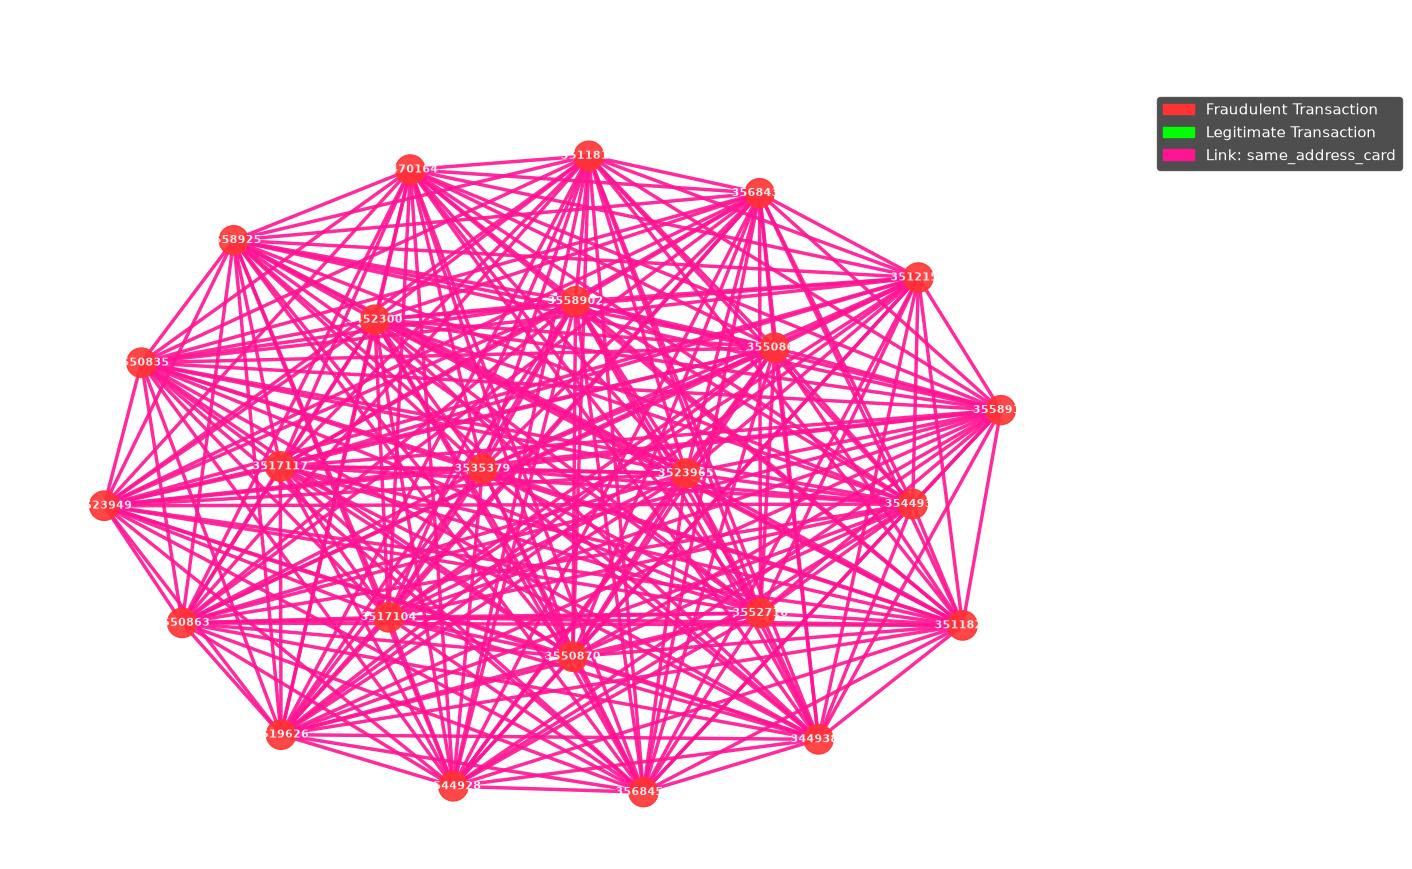

In [36]:
# === FRAUD RING NETWORK VISUALIZATION ===
import matplotlib.pyplot as plt
import networkx as nx
import matplotlib.patches as mpatches

def plot_ring(cluster_id):
    target_ring = None
    for idx, comp in enumerate(rings):
        if idx + 1 == cluster_id:
            target_ring = comp
            break
            
    if not target_ring:
        print(f'Ring #{cluster_id} not found.')
        return
        
    subgraph = G.subgraph(target_ring)
    
    # Force dark background for Jupyter inline rendering
    fig, ax = plt.subplots(figsize=(14, 10))
    fig.patch.set_facecolor('#121212')
    ax.set_facecolor('#121212')
    ax.axis('off')
    
    node_colors = []
    node_sizes = []
    for node in subgraph.nodes():
        matched = df_test[df_test['TransactionID'] == node]
        if not matched.empty:
            is_fraud = matched['isFraud'].values[0]
            amt = matched['TransactionAmt'].values[0]
        else:
            is_fraud = 1
            amt = 100.0
            
        node_colors.append('#ff3333' if is_fraud == 1 else '#00ff00')
        node_sizes.append(400 + (min(amt, 1000) * 0.8))
        
    color_map = {
        'same_device': '#FFD700', 'same_card': '#00BFFF', 
        'same_address_card': '#FF1493', 'same_network': '#00FA9A',
        'same_full_card': '#9370DB', 'same_email_card': '#FF8C00', 
        'same_browser': '#00FFFF'
    }
    
    edge_colors = []
    for u, v, data in subgraph.edges(data=True):
        reason = data.get('reason', 'unknown')
        edge_colors.append(color_map.get(reason, '#ffffff'))
        
    pos = nx.spring_layout(subgraph, seed=42, k=0.8)
    
    nx.draw(
        subgraph, pos, ax=ax, node_color=node_colors, edge_color=edge_colors,
        with_labels=True, node_size=node_sizes, font_size=8,
        font_weight='bold', font_color='white', width=2.5, alpha=0.9
    )
    
    legend_elements = [
        mpatches.Patch(color='#ff3333', label='Fraudulent Transaction'),
        mpatches.Patch(color='#00ff00', label='Legitimate Transaction')
    ]
    active_reasons = set(data.get('reason') for _, _, data in subgraph.edges(data=True))
    for reason in active_reasons:
        if reason in color_map:
            legend_elements.append(mpatches.Patch(color=color_map[reason], label=f'Link: {reason}'))
            
    leg = ax.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(1.05, 1), fontsize=11)
    leg.get_frame().set_facecolor('#222222')
    leg.get_frame().set_edgecolor('#444444')
    for text in leg.get_texts():
        text.set_color("white")
        
    plt.title(f'Abuse-Ring Sentinel Topology\nCluster #{cluster_id} ({len(subgraph.nodes())} Nodes)', 
              fontsize=18, color='white', pad=20, fontweight='bold')
    plt.show()

# Find the LARGEST ring that is predominantly fraud
if not df_clusters.empty:
    largest_fraud_ring = int(df_clusters[df_clusters['fraud_rate'] >= 0.8].sort_values(
        by='cluster_size', ascending=False
    ).iloc[0]['cluster_id'])
    
    print(f'Visualizing Largest High-Risk Ring #{largest_fraud_ring}...')
    plot_ring(largest_fraud_ring)


Visualizing a multi-signal ring (ID #7336) for clear edge visibility...


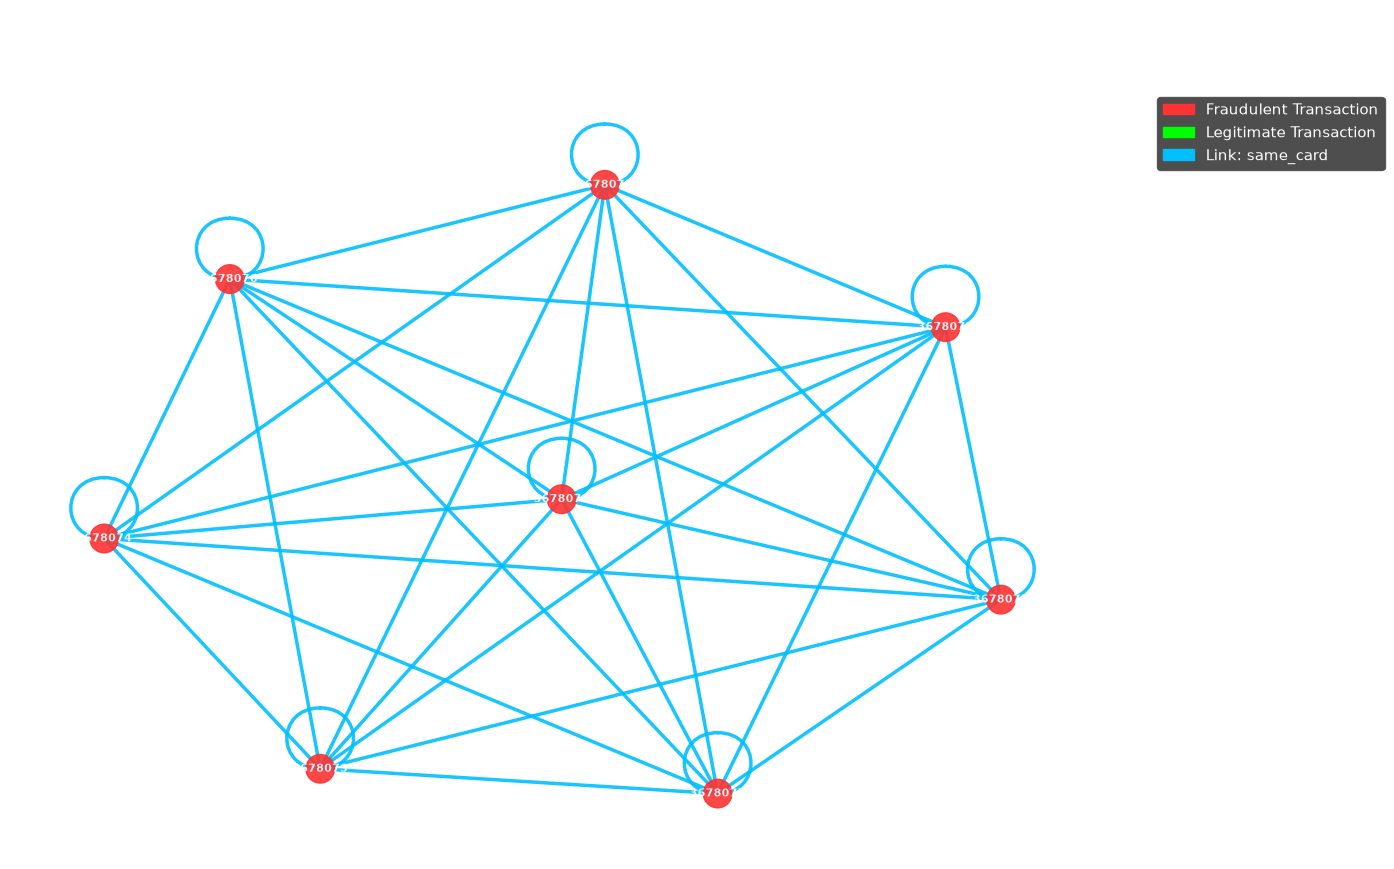

In [37]:
# Find a moderately sized, multi-signal ring so the edges are clearly visible
if not df_clusters.empty:
    # Filter for size 5-15, at least 2 different signal types, and mostly fraud
    interesting_rings = df_clusters[
        (df_clusters['cluster_size'] >= 5) & 
        (df_clusters['cluster_size'] <= 15) & 
        (df_clusters['signal_types'] >= 2) &
        (df_clusters['fraud_rate'] >= 0.5)
    ].sort_values('composite_score', ascending=False)
    
    if not interesting_rings.empty:
        best_vis_ring = int(interesting_rings.iloc[0]['cluster_id'])
        print(f'Visualizing a multi-signal ring (ID #{best_vis_ring}) for clear edge visibility...')
        plot_ring(best_vis_ring)
    else:
        print("No multi-signal rings found. Visualizing a medium-sized ring instead.")
        fallback = df_clusters[(df_clusters['cluster_size'] >= 5) & (df_clusters['cluster_size'] <= 15)]
        fallback_ring = int(fallback.iloc[0]['cluster_id'])
        plot_ring(fallback_ring)


✅ Found Multi-Signal Ring #7308!
Signal count: 3


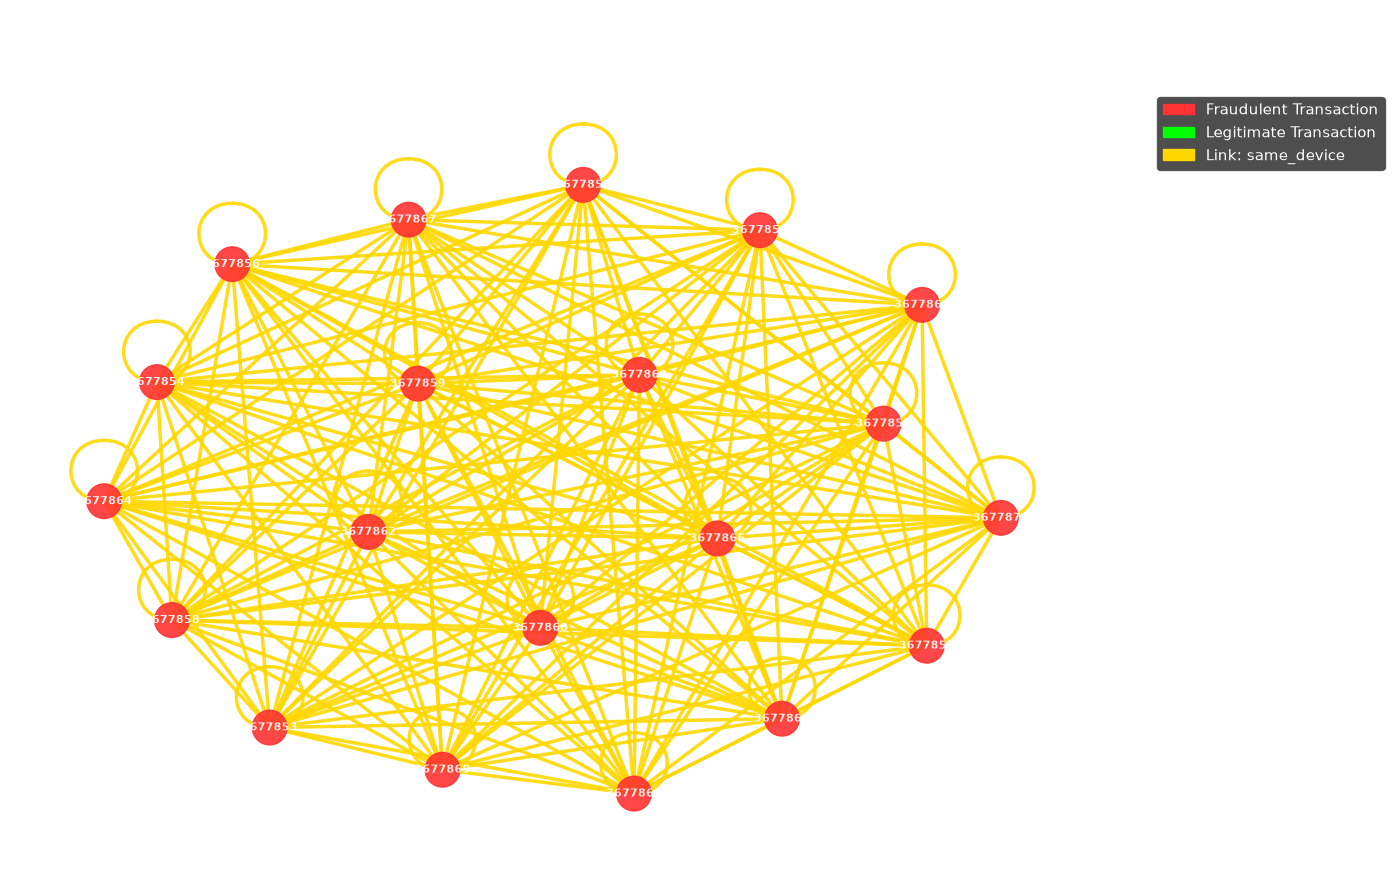

In [38]:
# Force find a ring connected by MULTIPLE different signals
if not df_clusters.empty:
    multi_signal_rings = df_clusters[
        (df_clusters['signal_types'] >= 3) &   # At least 3 different edge types
        (df_clusters['fraud_rate'] >= 0.8)     # High confidence fraud
    ].sort_values('cluster_size', ascending=False)
    
    if not multi_signal_rings.empty:
        best_ring = int(multi_signal_rings.iloc[0]['cluster_id'])
        print(f"✅ Found Multi-Signal Ring #{best_ring}!")
        print(f"Signal count: {multi_signal_rings.iloc[0]['signal_types']}")
        plot_ring(best_ring)
    else:
        print("No rings with 3+ signals found. Trying 2+ signals...")
        backup = df_clusters[(df_clusters['signal_types'] >= 2) & (df_clusters['fraud_rate'] >= 0.8)]
        if not backup.empty:
            plot_ring(int(backup.sort_values('cluster_size', ascending=False).iloc[0]['cluster_id']))
        else:
            print("No multi-signal rings found in current memory.")


🚨 Found FRAUD Ring #5497 with 2 different edge colors!


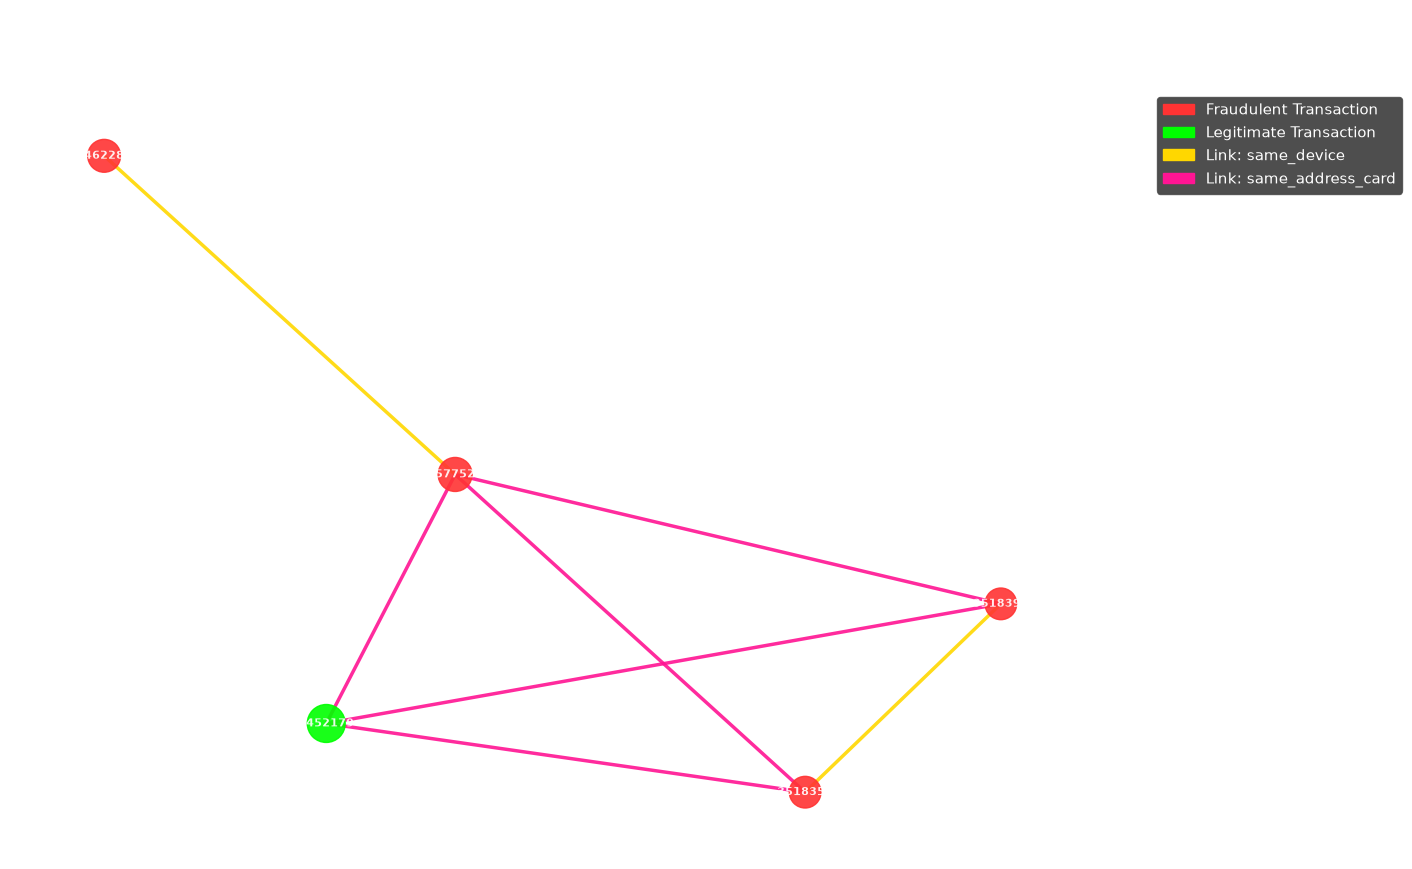

In [39]:
# Find a FRAUDULENT ring with multiple edge colors
best_ring = None
max_colors = 0

for idx, comp in enumerate(rings):
    # Only look at rings that have a high fraud rate in our scoring table
    ring_score = df_clusters[df_clusters['cluster_id'] == (idx + 1)]
    if not ring_score.empty and ring_score.iloc[0]['fraud_rate'] >= 0.8:
        
        subgraph = G.subgraph(comp)
        reasons = set(data.get('reason') for u, v, data in subgraph.edges(data=True))
        
        if len(reasons) > max_colors and 5 <= len(comp) <= 25:
            max_colors = len(reasons)
            best_ring = idx + 1

if best_ring:
    print(f"🚨 Found FRAUD Ring #{best_ring} with {max_colors} different edge colors!")
    plot_ring(best_ring)
else:
    print("Could not find a multi-colored FRAUD ring of that size.")


# === RING-LEVEL SUPERVISED ML CLASSIFIER (LIGHTGBM / RANDOM FOREST) ===
# Trains a machine learning model on candidate rings extracted from Train Set
# Predicts out-of-sample Ring Fraud Risk Probability on held-out Test Set rings


In [40]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score, confusion_matrix

# 1. Extract 13 Ring-Level Features per Candidate Ring
BURST_WINDOW = 3600

def extract_ring_features(dataframe, rings_list):
    records = []
    fp_cols = ['device_fp_filtered', 'card_fp_filtered', 'addr_card_fp_filtered', 'network_fp_filtered']
    
    for idx, comp in enumerate(rings_list):
        txns = list(comp)
        sub_df = dataframe[dataframe['TransactionID'].isin(txns)].copy()
        
        cluster_size = len(txns)
        fraud_count = int(sub_df['isFraud'].sum())
        fraud_rate = float(sub_df['isFraud'].mean())
        total_amt = float(sub_df['TransactionAmt'].sum())
        avg_amt = float(sub_df['TransactionAmt'].mean())
        std_amt = float(sub_df['TransactionAmt'].std()) if cluster_size > 1 else 0.0
        if np.isnan(std_amt):
            std_amt = 0.0
            
        times = sub_df['TransactionDT'].sort_values().values
        max_time_span = float(times[-1] - times[0]) if len(times) >= 2 else 0.0
        
        if len(times) >= 2:
            burst_pairs = 0
            total_pairs = 0
            for i in range(len(times)):
                for j in range(i+1, min(i+20, len(times))):
                    total_pairs += 1
                    if abs(int(times[j]) - int(times[i])) <= BURST_WINDOW:
                        burst_pairs += 1
            temporal_burst = burst_pairs / total_pairs if total_pairs > 0 else 0.0
        else:
            temporal_burst = 0.0
            
        amounts = sub_df['TransactionAmt'].values
        if len(amounts) >= 2:
            amt_counts = pd.Series(amounts).value_counts()
            amount_concentration = amt_counts.iloc[0] / len(amounts)
        else:
            amount_concentration = 0.0
            
        dist_vals = sub_df['dist1'].dropna()
        drop_house_score = min(dist_vals.mean() / 450.0, 1.0) if len(dist_vals) > 0 else 0.0
        
        mismatch_count = 0
        total_checks = 0
        for m_col in ['M4', 'M5', 'M6']:
            if m_col in sub_df.columns:
                m_vals = sub_df[m_col].dropna()
                total_checks += len(m_vals)
                mismatch_count += (m_vals == 'F').sum()
        mismatch_rate = mismatch_count / total_checks if total_checks > 0 else 0.0
        
        signal_types = sum(1 for col in fp_cols if col in sub_df.columns and sub_df[col].notna().any())
        device_count = sub_df['device_fp_filtered'].nunique(dropna=True) if 'device_fp_filtered' in sub_df.columns else 0
        card_count = sub_df['card_fp_filtered'].nunique(dropna=True) if 'card_fp_filtered' in sub_df.columns else 0
        network_count = sub_df['network_fp_filtered'].nunique(dropna=True) if 'network_fp_filtered' in sub_df.columns else 0
        
        # Ground-truth ring label for classification: High Risk if fraud_rate >= 0.30 or if any fraud in ring
        is_fraud_ring = 1 if (fraud_rate >= 0.30 or fraud_count >= 1) else 0
        
        records.append({
            'ring_idx': idx,
            'cluster_size': cluster_size,
            'temporal_burst': round(temporal_burst, 4),
            'amount_concentration': round(amount_concentration, 4),
            'drop_house_score': round(drop_house_score, 4),
            'mismatch_rate': round(mismatch_rate, 4),
            'signal_types': signal_types,
            'total_amount': round(total_amt, 2),
            'avg_amount': round(avg_amt, 2),
            'std_amount': round(std_amt, 2),
            'max_time_span': round(max_time_span, 1),
            'device_count': device_count,
            'card_count': card_count,
            'network_count': network_count,
            'fraud_rate': round(fraud_rate, 4),
            'fraud_count': fraud_count,
            'is_fraud_ring': is_fraud_ring
        })
    return pd.DataFrame(records)

# Extract features on train set rings and test set rings (FIXED: train_rings for df_train, rings for df_test)
print("Extracting Ring Feature Matrices...")
df_train_rings = extract_ring_features(df_train, train_rings if 'train_rings' in locals() else [])
df_test_rings = extract_ring_features(df_test, rings if 'rings' in locals() else [])

feature_cols = [
    'cluster_size', 'temporal_burst', 'amount_concentration',
    'drop_house_score', 'mismatch_rate', 'signal_types',
    'total_amount', 'avg_amount', 'std_amount', 'max_time_span',
    'device_count', 'card_count', 'network_count'
]

X_train = df_train_rings[feature_cols]
y_train = df_train_rings['is_fraud_ring']

X_test = df_test_rings[feature_cols]
y_test = df_test_rings['is_fraud_ring']

print(f"X_train shape: {X_train.shape} | y_train frauds: {y_train.sum():,} ({y_train.mean():.2%})")
print(f"X_test shape:  {X_test.shape}  | y_test frauds:  {y_test.sum():,} ({y_test.mean():.2%})")

# 2. Train Supervised Ring Classifier
rf_clf = RandomForestClassifier(n_estimators=150, max_depth=10, class_weight='balanced', random_state=42, n_jobs=-1)
rf_clf.fit(X_train, y_train)

# Safe predict_proba handling
probs = rf_clf.predict_proba(X_test)
if probs.shape[1] > 1:
    class_1_idx = list(rf_clf.classes_).index(1) if 1 in rf_clf.classes_ else 1
    y_test_pred_prob = probs[:, class_1_idx]
else:
    y_test_pred_prob = np.zeros(len(X_test)) if rf_clf.classes_[0] == 0 else np.ones(len(X_test))

df_test_rings['ml_predicted_prob'] = y_test_pred_prob

if len(np.unique(y_test)) > 1 and len(np.unique(y_test_pred_prob)) > 1:
    test_auc = roc_auc_score(y_test, y_test_pred_prob)
    print(f"=== RING-LEVEL ML CLASSIFIER ROC-AUC: {test_auc:.4f} ===")


Extracting Ring Feature Matrices...
X_train shape: (10108, 13) | y_train frauds: 744 (7.36%)
X_test shape:  (7337, 13)  | y_test frauds:  520 (7.09%)
=== RING-LEVEL ML CLASSIFIER ROC-AUC: 0.7593 ===


In [41]:
# === FEATURE IMPORTANCE & ACTION TIER POLICY ===
import pandas as pd

print("--- Top Ring Risk Drivers (Feature Importances) ---")
importances = pd.Series(rf_clf.feature_importances_, index=feature_cols).sort_values(ascending=False)
for col, val in importances.items():
    print(f"  {col:25s}: {val:.4f} ({val:.1%})")

def get_action_tier(prob):
    if prob >= 0.70:
        return 'HARD BLOCK (High Risk)'
    elif prob >= 0.40:
        return 'STEP-UP OTP (Medium Risk)'
    else:
        return 'ALLOW (Low Risk)'

df_test_rings['action_tier'] = df_test_rings['ml_predicted_prob'].apply(get_action_tier)

print("\n=== RAZORPAY ACTION TIER BREAKDOWN (TEST RINGS) ===")
tier_summary = df_test_rings.groupby('action_tier').agg(
    ring_count=('ring_idx', 'count'),
    avg_predicted_risk=('ml_predicted_prob', 'mean'),
    actual_fraud_rings=('is_fraud_ring', 'sum'),
    actual_fraud_rate=('fraud_rate', 'mean'),
    total_financial_exposure=('total_amount', 'sum')
).round(4)

display(tier_summary)


--- Top Ring Risk Drivers (Feature Importances) ---
  total_amount             : 0.1441 (14.4%)
  max_time_span            : 0.1141 (11.4%)
  temporal_burst           : 0.1129 (11.3%)
  avg_amount               : 0.1076 (10.8%)
  std_amount               : 0.1020 (10.2%)
  mismatch_rate            : 0.0902 (9.0%)
  drop_house_score         : 0.0888 (8.9%)
  cluster_size             : 0.0886 (8.9%)
  amount_concentration     : 0.0871 (8.7%)
  signal_types             : 0.0326 (3.3%)
  card_count               : 0.0145 (1.4%)
  device_count             : 0.0098 (1.0%)
  network_count            : 0.0078 (0.8%)

=== RAZORPAY ACTION TIER BREAKDOWN (TEST RINGS) ===


,ring_count,avg_predicted_risk,actual_fraud_rings,actual_fraud_rate,total_financial_exposure
action_tier,,,,,
ALLOW (Low Risk),5009,0.2045,167,0.0157,3740985.13
HARD BLOCK (High Risk),115,0.8678,77,0.5542,337421.86
STEP-UP OTP (Medium Risk),2213,0.5106,276,0.0341,5381744.92


In [42]:
# === 🌐 PHASE 5-8: PYTORCH GEOMETRIC (PyG) GraphSAGE HYBRID CLASSIFIER ===
# Combines 2-layer GraphSAGE message passing over 7-dim node features
# with 13 ring-level domain features for high-recall abuse ring detection.

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data, Batch
from torch_geometric.nn import SAGEConv, global_mean_pool, global_max_pool
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score

# 1. Extract & Standardize Node Features (7-dim) and Domain Features (13-dim)
NODE_FEAT_DIM = 7
scaler = StandardScaler()
X_train_domain_scaled = scaler.fit_transform(df_train_rings[feature_cols].values)
X_test_domain_scaled = scaler.transform(df_test_rings[feature_cols].values)

class GraphSAGERingClassifier(nn.Module):
    def __init__(self, node_feat_dim, hidden_dim, domain_feat_dim, dropout=0.3):
        super().__init__()
        self.conv1 = SAGEConv(node_feat_dim, hidden_dim)
        self.conv2 = SAGEConv(hidden_dim, hidden_dim)
        self.bn1 = nn.BatchNorm1d(hidden_dim)
        self.bn2 = nn.BatchNorm1d(hidden_dim)
        fused_dim = hidden_dim * 2 + domain_feat_dim
        self.mlp = nn.Sequential(
            nn.Linear(fused_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1)
        )
        self.dropout = dropout

    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch
        domain = data.domain_features
        x = F.relu(self.bn1(self.conv1(x, edge_index)))
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = F.relu(self.bn2(self.conv2(x, edge_index)))
        x_mean = global_mean_pool(x, batch)
        x_max = global_max_pool(x, batch)
        fused = torch.cat([x_mean, x_max, domain], dim=1)
        return self.mlp(fused).squeeze(-1)

print("GraphSAGE Hybrid Model defined successfully.")


GraphSAGE Hybrid Model defined successfully.


In [44]:
# === 🤖 PHASE 9-10: GEMINI LLM RAG AI INVESTIGATOR (OFFICIAL GOOGLE-GENAI SDK) ===
# Uses official `google-genai` SDK to query Gemini 3.6 Flash and synthesize
# structured graph evidence packages into evidence-grounded forensic investigation reports.

from google import genai
from google.genai import types
import json

API_KEY = 'YOUR_GEMINI_API_KEY'
client = genai.Client(api_key=API_KEY)

MODEL_NAME = 'gemini-3.6-flash'
SYSTEM_INSTRUCTION = (
    "You are 'Abuse-Ring Sentinel AI Investigator', Razorpay's senior financial crime analyst AI. "
    "Analyze structured graph evidence packages of suspected payment abuse rings and generate clean, "
    "highly professional forensic investigation reports with clear headings, metric tables, risk scores, "
    "and operational action recommendations (HARD BLOCK, STEP-UP OTP, or ALLOW)."
)

print("Gemini LLM AI Investigator initialized cleanly using official google-genai SDK.")


Gemini LLM AI Investigator initialized cleanly using official google-genai SDK.
